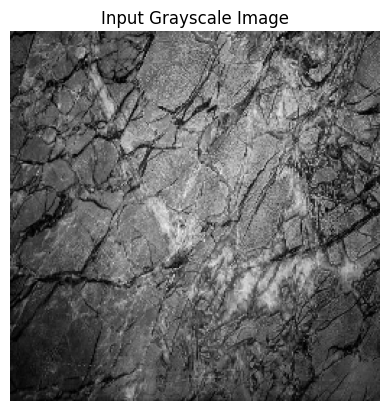

GLCM shape: (8, 8)
GLCM (normalized):
[[5.58210784e-02 3.08517157e-02 9.74264706e-03 2.94117647e-03
  7.96568627e-04 1.22549020e-04 0.00000000e+00 0.00000000e+00]
 [3.01317402e-02 1.20281863e-01 5.89001225e-02 1.41084559e-02
  4.25857843e-03 7.35294118e-04 0.00000000e+00 0.00000000e+00]
 [9.72732843e-03 5.71997549e-02 1.39200368e-01 5.99264706e-02
  1.33884804e-02 1.83823529e-03 6.12745098e-05 0.00000000e+00]
 [2.75735294e-03 1.45067402e-02 5.86703431e-02 9.98161765e-02
  4.33823529e-02 6.34191176e-03 2.29779412e-04 1.53186275e-05]
 [6.28063725e-04 4.39644608e-03 1.34957108e-02 4.35355392e-02
  5.34160539e-02 1.33731618e-02 4.44240196e-04 0.00000000e+00]
 [2.29779412e-04 6.43382353e-04 2.31311275e-03 5.49938725e-03
  1.36948529e-02 1.01562500e-02 7.65931373e-04 0.00000000e+00]
 [0.00000000e+00 1.53186275e-05 7.65931373e-05 2.60416667e-04
  4.13602941e-04 7.35294118e-04 1.37867647e-04 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.53186275e-05 0.00000000e+00
  0.00000000e+00 0.000000

In [ ]:


import cv2
import numpy as np
import matplotlib.pyplot as plt
image_path = "/content/texture.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Could not open or find the image: {image_path}")

img = cv2.resize(img, (256, 256))

plt.imshow(img, cmap='gray')
plt.title("Input Grayscale Image")
plt.axis("off")
plt.show()
levels = 8
step = 256 // levels
quantized = (img // step).astype(np.uint8)
def compute_glcm(image, levels=8):
    h, w = image.shape
    glcm = np.zeros((levels, levels), dtype=np.uint32)

    for y in range(h):
        for x in range(w - 1):
            i = image[y, x]
            j = image[y, x + 1]
            glcm[i, j] += 1
    glcm = glcm.astype(np.float64)
    glcm /= glcm.sum()
    return glcm

glcm = compute_glcm(quantized, levels=levels)

print("GLCM shape:", glcm.shape)
print("GLCM (normalized):")
print(glcm)
def glcm_contrast(glcm):
    levels = glcm.shape[0]
    contrast = 0.0
    for i in range(levels):
        for j in range(levels):
            contrast += (i - j) ** 2 * glcm[i, j]
    return contrast

def glcm_energy(glcm):
    return np.sum(glcm ** 2)

def glcm_homogeneity(glcm):
    levels = glcm.shape[0]
    homogeneity = 0.0
    for i in range(levels):
        for j in range(levels):
            homogeneity += glcm[i, j] / (1.0 + abs(i - j))
    return homogeneity

def glcm_correlation(glcm):
    levels = glcm.shape[0]
    # Indices
    i_indices = np.arange(levels)
    j_indices = np.arange(levels)

    # Means
    px = glcm.sum(axis=1)
    py = glcm.sum(axis=0)
    mean_x = np.sum(i_indices * px)
    mean_y = np.sum(j_indices * py)

    # Standard deviations
    std_x = np.sqrt(np.sum(((i_indices - mean_x) ** 2) * px))
    std_y = np.sqrt(np.sum(((j_indices - mean_y) ** 2) * py))

    # Correlation
    corr = 0.0
    for i in range(levels):
        for j in range(levels):
            if std_x > 0 and std_y > 0:
                corr += ((i - mean_x) * (j - mean_y) * glcm[i, j]) / (std_x * std_y)
    return corr

contrast = glcm_contrast(glcm)
energy = glcm_energy(glcm)
homogeneity = glcm_homogeneity(glcm)
correlation = glcm_correlation(glcm)

print("\n--- GLCM Features (distance=1, angle=0°) ---")
print(f"Contrast    : {contrast:.4f}")
print(f"Energy      : {energy:.4f}")
print(f"Homogeneity : {homogeneity:.4f}")
print(f"Correlation : {correlation:.4f}")


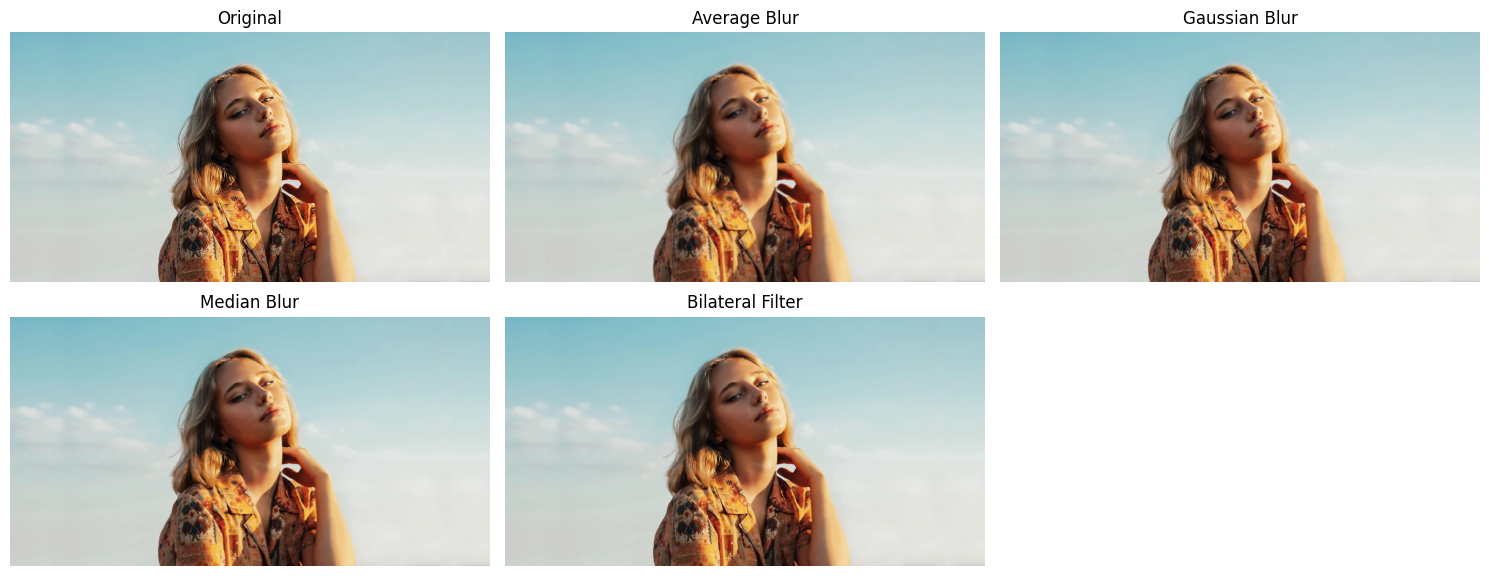

In [ ]:
# 1. Import libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 2. Read image
# Change the path/name if needed
img = cv2.imread('/content/women.jpg')        # reads in BGR format
if img is None:
    raise ValueError("Image not found. Check the file name and path.")

# Convert BGR -> RGB for correct display in matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 3. Apply different smoothing filters

# (a) Average / Box filter (5x5 kernel)
avg_blur = cv2.blur(img_rgb, (5, 5))

# (b) Gaussian Blur (5x5 kernel, sigmaX=0 lets OpenCV choose)
gaussian_blur = cv2.GaussianBlur(img_rgb, (5, 5), 0)

# (c) Median Blur (kernel size must be odd: 3,5,7,...)
median_blur = cv2.medianBlur(img_rgb, 5)

# (d) Bilateral filter (optional)
# d = neighborhood size, sigmaColor & sigmaSpace control smoothing
bilateral_blur = cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)

# 4. Show results
titles = ['Original', 'Average Blur', 'Gaussian Blur', 'Median Blur', 'Bilateral Filter']
images = [img_rgb, avg_blur, gaussian_blur, median_blur, bilateral_blur]

plt.figure(figsize=(15, 6))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
